### **Introdução**

Neste notebook vamos trabalhar com vetores linha. Isto faz o fluxo de operações matriciais ocorrer no mesmo sentido do fluxo de informações (da esquerda para a direita).

IMPORTANTE: quando temos $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$ devemos lembrar:

- A resposta obtida para uma medida efetuada em $|\psi\rangle$ é $|0\rangle$ ou $|1\rangle$. $|0\rangle$ e $|1\rangle$ representam (na forma de vetores) o resultado das medidas. Estes resultados podem ser, por exemplo: -1 Volt e + 1 Volt, a presença ou não de um pixel em uma tela, etc...

- Os valores $\alpha$ e $\beta$ associados aos estados $|0\rangle$ ou $|1\rangle$ de $|\psi\rangle$ NÃO são observáveis diretamente. Eles se manifestam através da probabilidade de se obter como resultado de uma medida em $|\psi\rangle$, o valor associado ao vetor $|0\rangle$ ou o valor associado ao vetor $|1\rangle$

### **Deustch**

In [ ]:
# Matrizes numéricas de transformação - Algoritmo de Deustch
import numpy as np
x = np.array([[1, 0]])
y = np.array([[0, 1]])
H = np.array([[1, 1],
              [1,-1]])
I = np.array([[1,0],
              [0,1]])

print("Inicialização de x em <0| e y em <1|")
print(np.kron(x,y), "\n")

print("|x> = <01|, <01|.H2")
print(np.kron(x,y).dot(np.kron(H,H)), "\n")

R = lambda x,y,M: np.kron(x,y).dot(np.kron(H,H)).dot(M).dot(np.kron(H,I))
print("------------------------------------------------")
print("Resultados <01.H2.M.HI", "\n")
#-------------------------------------------------------------
print("Mc0 -> f(0)=0, f(1)=0")
Mc0 = np.array([[1,0,0,0],
                [0,1,0,0],
                [0,0,1,0],
                [0,0,0,1]]); print(R(x,y,Mc0), "\n")
#-------------------------------------------------------------
print("Mc1 -> f(0)=1, f(1)=1")
Mc1 = np.array([[0,1,0,0],
                [1,0,0,0],
                [0,0,0,1],
                [0,0,1,0]]); print(R(x,y,Mc1), "\n")
#-------------------------------------------------------------
print("Mb0 -> f(0)=0, f(1)=1")
Mb0 = np.array([[1,0,0,0],
                [0,1,0,0],
                [0,0,0,1],
                [0,0,1,0]]); print(R(x,y,Mb0), "\n")
#-------------------------------------------------------------
print("Mb1 -> f(0)=1, f(1)=0")
Mb1 = np.array([[0,1,0,0],
                [1,0,0,0],
                [0,0,1,0],
                [0,0,0,1]]); print(R(x,y,Mb1), "\n")

#-------------------------------------------------------------
print("------------------------------------------------")
print("Observe o que ocorre se medirmos os qubits na saida da função")
print("Abaixo, o resultado de <01.H2.Mc0 [f(0)=0 e f(1)=0]")
print(np.kron(x,y).dot(np.kron(H,H)).dot(Mc0), "\n")


Inicialização de x em <0| e y em <1|
[[0 1 0 0]] 

|x> = <01|, <01|.H2
[[ 1 -1  1 -1]] 

------------------------------------------------
Resultados <01.H2.M.HI 

f(0)=0, f(1)=0
[[ 2 -2  0  0]] 

f(0)=1, f(1)=1
[[-2  2  0  0]] 

f(0)=0, f(1)=1
[[ 0  0  2 -2]] 

f(0)=1, f(1)=0
[[ 0  0 -2  2]] 

------------------------------------------------
Observe o que ocorre se medirmos os qubits na saida da função
Abaixo, o resultado de <01.H2.Mc0 [f(0)=0 e f(1)=0]
[[ 1 -1  1 -1]] 



##### **Deustch Algorithm - Matriz Simbólica de Transformação**

**Matriz Genérica de Transformação - 1a Parte - Elementos Nulos**

A tabela que converte os estados da entrada do oráculo $M$ para a saída é apresentada a seguir:

$$\begin{array}{cc|cc}
x&y&x&f(x) \oplus y\\
\hline
0&0&0&f(0) \\
0&1&0&f(0)' \\
1&0&1&f(1) \\
1&1&1&f(1)'
\end{array}$$

A matriz genérica $M$ que representa uma transformação de um vetor de 4 dimensões para outro vetor de 4 dimensões pode ser representada como:

$$
M_1 = \left[
\begin{array}{c:c:c:c}
a_{11} & a_{12} & a_{13} & a_{14} \\
\hdashline
a_{21} & a_{22} & a_{23} & a_{24} \\
\hdashline
a_{31} & a_{32} & a_{33} & a_{34} \\
\hdashline
a_{41} & a_{42} & a_{43} & a_{44}
\end{array}
\right]
$$


Não existe nenhuma transformação na qual o valor de $x$ se altera (de 0 para 1 ou vice-versa), sendo assim a matriz $M$ no momento torna-se:

$$
M_1 = \left[
\begin{array}{c:c:c:c}
a_{11} & a_{12} & 0 & 0 \\
\hdashline
a_{21} & a_{22} & 0 & 0 \\
\hdashline
0 & 0 & a_{33} & a_{34} \\
\hdashline
0 & 0 & a_{43} & a_{44}
\end{array}
\right]
$$

**Matriz Genérica de Transformação - 2a Parte - $f(0) = 0$**

A tabela que converte os estados da entrada do oráculo $M$ para a saída é apresentada a seguir:

$$\begin{array}{cc|cc}
x&y&x&f(x) \oplus y\\
\hline
0&0&0&f(0) \\
0&1&0&f(0)' \\
1&0&1&f(1) \\
1&1&1&f(1)'
\end{array}$$

Suponha agora que $f(0) = 0$. Sendo assim $f(0)'=1$ A tabela então fica:

$$\begin{array}{cc|cc}
x&y&x&f(x) \oplus y\\
\hline
0&0&0&0 \\
0&1&0&1 \\
1&0&1&f(1) \\
1&1&1&f(1)'
\end{array}$$

A matriz correspondente a transformação $|x,y\rangle \rightarrow |x,f(x) \oplus y\rangle$ no momento seria:

$$M_2 = \left[
\begin{array}{c:c:c:c}
1 & a_{12} & 0 & 0 \\
\hdashline
a_{21} & 1 & 0 & 0 \\
\hdashline
0 & 0 & a_{33} & a_{34} \\
\hdashline
0 & 0 & a_{43} & a_{44}
\end{array}
\right]$$

Como $f(0)'=1$ a matriz correspondente a transformação $|x,y\rangle \rightarrow |x,f(x) \oplus y\rangle$ no momento torna-se:

$$M_2 = \left[
\begin{array}{c:c:c:c}
f(0)' & a_{12} & 0 & 0 \\
\hdashline
a_{21} & f(0)' & 0 & 0 \\
\hdashline
0 & 0 & a_{33} & a_{34} \\
\hdashline
0 & 0 & a_{43} & a_{44}
\end{array}
\right]$$

**Matriz Genérica de Transformação - 3a Parte - $f(1) = 0$**

A tabela que converte os estados da entrada do oráculo $M$ para a saída é apresentada a seguir:

$$\begin{array}{cc|cc}
x&y&x&f(x) \oplus y\\
\hline
0&0&0&f(0) \\
0&1&0&f(0)' \\
1&0&1&f(1) \\
1&1&1&f(1)'
\end{array}$$

Suponha agora que $f(1) = 0$. Sendo assim $f(1)'=1$ A tabela então fica:

$$\begin{array}{cc|cc}
x&y&x&f(x) \oplus y\\
\hline
0&0&0&f(0) \\
0&1&0&f(0)' \\
1&0&1&0 \\
1&1&1&1
\end{array}$$

A matriz correspondente a transformação $|x,y\rangle \rightarrow |x,f(x) \oplus y\rangle$ no momento seria:

$$M_3 = \left[
\begin{array}{c:c:c:c}
f(0)' & a_{12} & 0 & 0 \\
\hdashline
a_{21} & f(0)' & 0 & 0 \\
\hdashline
0 & 0 & 1 & a_{34} \\
\hdashline
0 & 0 & a_{43} & 1
\end{array}
\right]$$

Como $f(1)'=1$ a matriz correspondente a transformação $|x,y\rangle \rightarrow |x,f(x) \oplus y\rangle$ no momento torna-se:

$$M_3 = \left[
\begin{array}{c:c:c:c}
f(0)' & a_{12} & 0 & 0 \\
\hdashline
a_{21} & f(0)' & 0 & 0 \\
\hdashline
0 & 0 & f(1)' & a_{34} \\
\hdashline
0 & 0 & a_{43} & f(1)'
\end{array}
\right]$$

**Matriz Genérica de Transformação - 4a Parte - $f(0) = 1$**

A tabela que converte os estados da entrada do oráculo $M$ para a saída é apresentada a seguir:

$$\begin{array}{cc|cc}
x&y&x&f(x) \oplus y\\
\hline
0&0&0&f(0) \\
0&1&0&f(0)' \\
1&0&1&f(1) \\
1&1&1&f(1)'
\end{array}$$

Suponha agora que $f(0) = 1$. Sendo assim $f(0)'=0$ A tabela então fica:

$$\begin{array}{cc|cc}
x&y&x&f(x) \oplus y\\
\hline
0&0&0&1 \\
0&1&0&0 \\
1&0&1&f(1) \\
1&1&1&f(1)'
\end{array}$$

A matriz correspondente a transformação $|x,y\rangle \rightarrow |x,f(x) \oplus y\rangle$ no momento seria:

$$M_4 = \left[
\begin{array}{c:c:c:c}
f(0)' & 1 & 0 & 0 \\
\hdashline
1 & f(0)' & 0 & 0 \\
\hdashline
0 & 0 & f(1)' & a_{34} \\
\hdashline
0 & 0 & a_{43} & f(1)'
\end{array}
\right]$$

Como $f(0)=1$ a matriz correspondente a transformação $|x,y\rangle \rightarrow |x,f(x) \oplus y\rangle$ no momento torna-se:

$$M_4 = \left[
\begin{array}{c:c:c:c}
f(0)' & f(0) & 0 & 0 \\
\hdashline
f(0) & f(0)' & 0 & 0 \\
\hdashline
0 & 0 & f(1)' & a_{34} \\
\hdashline
0 & 0 & a_{43} & f(1)'
\end{array}
\right]$$

**Matriz Genérica de Transformação - 5a Parte - $f(1) = 1$**

A tabela que converte os estados da entrada do oráculo $M$ para a saída é apresentada a seguir:

$$\begin{array}{cc|cc}
x&y&x&f(x) \oplus y\\
\hline
0&0&0&f(0) \\
0&1&0&f(0)' \\
1&0&1&f(1) \\
1&1&1&f(1)'
\end{array}$$

Suponha agora que $f(1) = 1$. Sendo assim $f(1)'=0$ A tabela então fica:

$$\begin{array}{cc|cc}
x&y&x&f(x) \oplus y\\
\hline
0&0&0&f(0) \\
0&1&0&f(0)' \\
1&0&1&1 \\
1&1&1&0
\end{array}$$

A matriz correspondente a transformação $|x,y\rangle \rightarrow |x,f(x) \oplus y\rangle$ no momento seria:

$$M_5 = \left[
\begin{array}{c:c:c:c}
f(0)' & 1 & 0 & 0 \\
\hdashline
1 & f(0)' & 0 & 0 \\
\hdashline
0 & 0 & f(1)' & 1 \\
\hdashline
0 & 0 & 1 & f(1)'
\end{array}
\right]$$

Como $f(1)=1$ a matriz correspondente a transformação $|x,y\rangle \rightarrow |x,f(x) \oplus y\rangle$ no momento torna-se:

$$M_5 = \left[
\begin{array}{c:c:c:c}
f(0)' & f(0) & 0 & 0 \\
\hdashline
f(0) & f(0)' & 0 & 0 \\
\hdashline
0 & 0 & f(1)' & f(1) \\
\hdashline
0 & 0 & f(1) & f(1)'
\end{array}
\right]$$

**Matriz Genérica de Transformação**

Sendo assim, a matriz genérica de transformação será:

$$M = \left[
\begin{array}{c:c:c:c}
f(0)' & f(0) & 0 & 0 \\
\hdashline
f(0) & f(0)' & 0 & 0 \\
\hdashline
0 & 0 & f(1)' & f(1) \\
\hdashline
0 & 0 & f(1) & f(1)'
\end{array}
\right]$$

In [ ]:
import sympy as sp
from sympy import Matrix
from sympy import kronecker_product as kron

x = Matrix([[1, 0]])
y = Matrix([[0, 1]])
H = Matrix([[1, 1],
            [1,-1]])
I = Matrix([[1,0],
            [0,1]])

f0, f0L, f1, f1L = sp.symbols("f0 f0L f1 f1L")

In [ ]:
M = Matrix([[f0L,   f0,    0,     0],
            [ f0,  f0L,    0,     0],
            [  0,    0,  f1L,    f1],
            [  0,    0,   f1,   f1L]]); M

Matrix([
[f0L,  f0,   0,   0],
[ f0, f0L,   0,   0],
[  0,   0, f1L,  f1],
[  0,   0,  f1, f1L]])

In [ ]:
# Transformação Algébrica Genérica
kron(x,y)*(kron(H,H))*M*kron(H,I)

Matrix([[-f0 + f0L - f1 + f1L, f0 - f0L + f1 - f1L, -f0 + f0L + f1 - f1L, f0 - f0L - f1 + f1L]])

In [ ]:
# Funções constantes f(0)=f(1)
# Observe que os dois primeiros estados são não nulos, logo |00> + |01>
# O primeiro qubit é sempre |0> para funções constantes
(kron(x,y)*(kron(H,H))*M*kron(H,I)).subs(f1,f0).subs(f1L,f0L)

Matrix([[-2*f0 + 2*f0L, 2*f0 - 2*f0L, 0, 0]])

In [ ]:
# Funções balanceadas f(0)=f'(1)
# Observe que os dois ultimos estados são não nulos, logo |10> + |11>
# O primeiro qubit é sempre |1> para funções balanceadas
(kron(x,y)*(kron(H,H))*M*kron(H,I)).subs(f1,f0L).subs(f1L,f0)

Matrix([[0, 0, -2*f0 + 2*f0L, 2*f0 - 2*f0L]])

In [ ]:
# Resumo: fizemos uma única chamada (ao oráculo M) e uma única medida (ao qubit |x> de saida)
#   e conseguimos obter uma resposta que seriam necessárias duas chamadas à função f(x) e
#   duas medições do bit x

### **Grover**

In [50]:
# Grover com f(101)=1 demais iguais a 0
import numpy as np

# Inicialização dos qubits <x| em <0|
x = np.array([[1,0]])
x3 = np.kron(np.kron(x,x),x)

# Inicialização do qubit <y| em <1|
y = np.array([[0,1]])

# Status <yx3|
yx3 = np.kron(y,x3)
print("yx3 =", yx3, "\n")

# Matriz H (gate hadamard)
H = np.array([[1, 1],
              [1,-1]])
H2 = np.kron(H,H)
H3 = np.kron(H2,H)
H4 = np.kron(H2,H2);

# Matriz I2 (identidade) (executa fan-out)
I2 = np.array([[1,0],
               [0,1]])

# Grover com f(101)=1 demais iguais a 0
# A matriz M implementa o Oráculo, isto é o
#  banco de dados estilo quântico
# Trocar linha no.5 pela no.13
M = np.eye(16,dtype=int);
M[[5,13],:] = M[[13,5],:]
#print("M = ")
#print(M, "\n")

# Circuito após <yx|.H4
print("yx3.H4 =", yx3.dot(H4), "\n")

# Circuito em si até a saida do Oráculo
print("yx3.H4.M =", yx3.dot(H4).dot(M), "\n")

# n = 3, 2^n = 8, Matriz A composta de 1/8
# Matriz de Inversão à média Minv = 2*A-I
Minv = 2*(1/(2**3))*np.ones((8,8)) - np.eye(8)

# 1a inversão
print("yx3.H4.M.(I x Minv) =")
print(yx3.dot(H4).dot(M).dot(np.kron(I2,Minv)), "\n")

# Função para Inversão de fase e Inversão à média
grover = lambda bra: bra.dot(M).dot(np.kron(I2,Minv))
bra1 = yx3.dot(H4)
bra2 = grover(bra1)
bra3 = grover(bra2)
print("yx3.H4.M.(I x Minv).M.(I x Minv) =")
print(bra3, "\n")

m_bra3_2 = bra3.dot(bra3.T)
min_bra3 = np.min(bra3)
max_bra3 = np.max(bra3)
print("P[min(bra3) + max(bra3)] =",
      (min_bra3**2 + max_bra3**2)/m_bra3_2, "\n")

bra4 = bra3.dot(np.kron(H,np.eye(8)))
print("yx3.H4.M.(I x Minv).M.(I x Minv).(H x I3) =")
print(bra4, "\n")

print("P[max(bra4)] =",
      np.max(bra4)**2/bra4.dot(bra4.T)[0,0])

yx3 = [[0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]] 

yx3.H4 = [[ 1  1  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1]] 

yx3.H4.M = [[ 1  1  1  1  1 -1  1  1 -1 -1 -1 -1 -1  1 -1 -1]] 

yx3.H4.M.(I x Minv) =
[[ 0.5  0.5  0.5  0.5  0.5  2.5  0.5  0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -2.5
  -0.5 -0.5]] 

yx3.H4.M.(I x Minv).M.(I x Minv) =
[[-0.25 -0.25 -0.25 -0.25 -0.25  2.75 -0.25 -0.25  0.25  0.25  0.25  0.25
   0.25 -2.75  0.25  0.25]] 

P[min(bra3) + max(bra3)] = [[0.9453125]] 

yx3.H4.M.(I x Minv).M.(I x Minv).(H x I3) =
[[ 0.   0.   0.   0.   0.   0.   0.   0.  -0.5 -0.5 -0.5 -0.5 -0.5  5.5
  -0.5 -0.5]] 

P[max(bra4)] = 0.9453125


### **FFT**

Para lembrar:

Suponha $n = 4$. Vamos transformar a multiplicação de uma matriz 4x4 por um vetor 4x1 ($n^2 = 16$ produtos) em ($n \log_2{n} = 8$ produtos)

$$W = e^{\frac{2 \pi j}{n}}$$

$$W_4 = e^{\frac{2 \pi j}{4}} = j$$

$$W_2 = e^{\frac{2 \pi j}{2}} = -1$$

A DFT para uma sequência de 4 pontos seria:
$$
\begin{array}{ccc}
\begin{bmatrix}
F_0 \\
F_1 \\
F_2 \\
F_3
\end{bmatrix}
&
=
&
\begin{bmatrix}
1 & 1       & 1 & 1 \\
1 & W_4     & W_4^{2} & W_4^{3} \\
1 & W_4^{2} & W_4^{4} & W_4^{6} \\
1 & W_4^{3} & W_4^{6} & W_4^{9}
\end{bmatrix}
&
.
&
\begin{bmatrix}
f_0 \\
f_1 \\
f_2 \\
f_3
\end{bmatrix}
\end{array}
$$

$$
\begin{array}{ccc}
\begin{bmatrix}
F_0 \\
F_1 \\
F_2 \\
F_3
\end{bmatrix}
&
=
&
\begin{bmatrix}
1 & 1     & 1     & 1 \\
1 & j     & j^{2} & j^{3} \\
1 & j^{2} & j^{4} & j^{6} \\
1 & j^{3} & j^{6} & j^{9}
\end{bmatrix}
&
.
&
\begin{bmatrix}
f_0 \\
f_1 \\
f_2 \\
f_3
\end{bmatrix}
\end{array}
$$

$$
\begin{array}{ccc}
\begin{bmatrix}
F_0 \\
F_1 \\
F_2 \\
F_3
\end{bmatrix}
&
=
&
\begin{bmatrix}
1 & 1  & 1     & 1 \\
1 & j  & -1 & -j \\
1 & -1 & 1 & 1 \\
1 & -j & -1 & -j
\end{bmatrix}
&
.
&
\begin{bmatrix}
f_0 \\
f_1 \\
f_2 \\
f_3
\end{bmatrix}
\end{array}
$$

A multiplicação em 8 passos seria feita de acordo com a sequência abaixo:

$$
\begin{array}{ccc}
\begin{bmatrix}
F_0 \\
F_1 \\
F_2 \\
F_3
\end{bmatrix}
&
=
&
\begin{bmatrix}
1 & 0  & 1 & 0 \\
0 & 1  & 0 & j \\
1 & 0 & -1 & 0 \\
0 & 1 & 0 & -j
\end{bmatrix}
&
.
&
\begin{bmatrix}
1 & 1  & 0 & 0 \\
1 & -1  & 0 & 0 \\
0 & 0 & 1 & 1 \\
0 & 0 & 1 & -1
\end{bmatrix}
&
.
&
\begin{bmatrix}
1 & 0  & 0 & 0 \\
0 & 0  & 1 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}
&
\begin{bmatrix}
f_0 \\
f_1 \\
f_2 \\
f_3
\end{bmatrix}
\end{array}
$$

$$
\begin{array}{ccc}
\begin{bmatrix}
F_0 \\
F_1 \\
F_2 \\
F_3
\end{bmatrix}
&
=
&
\begin{bmatrix}
I_2 & D_{4_2} \\
I_2 & -D_{4_2} \\
\end{bmatrix}
&
.
&
\begin{bmatrix}
DFT_2 & Z_2 \\
Z_2   & DFT_2 \\
\end{bmatrix}
&
.
&
\begin{bmatrix}
P_{even}  \\
P_{odd}  \\
\end{bmatrix}
&
.
&
\begin{bmatrix}
f_0 \\
f_1 \\
f_2 \\
f_3
\end{bmatrix}
\end{array}
$$

In [ ]:
def chop(x, tol=1.e-14):
  r = np.real(x)
  if abs(r)<tol:
    r = 0

  i = np.imag(x)
  if abs(i)<tol:
    i = 0

  if i == 0:
    n = r
  elif r == 0:
    n = i*1j
  else:
    n = r + i*1j
  return(n)

import numpy as np
a = 1e-16 + 1e-16*1j
b = 1e-16 + 1j
c = 1 + 1e-16*1j
chop(a), chop(b), chop(c)

(0, 1j, 1.0)

In [ ]:
n = 4
w4 = np.exp(2*np.pi*1j/n)
w4 = chop(w4)
w4

1j

In [ ]:
F4 = np.zeros([4,4], dtype=complex)
for i in range(4):
    for j in range(4):
        F4[i,j] = w4**(i*j)
F4

array([[ 1.+0.j,  1.+0.j,  1.+0.j,  1.+0.j],
       [ 1.+0.j,  0.+1.j, -1.+0.j, -0.-1.j],
       [ 1.+0.j, -1.+0.j,  1.+0.j, -1.+0.j],
       [ 1.+0.j, -0.-1.j, -1.+0.j,  0.+1.j]])

In [ ]:
I2 = np.array([[1,0],[0,1]]); I2

array([[1, 0],
       [0, 1]])

In [ ]:
D2_4 = np.zeros([2,2], dtype=complex)
for i in range(2):
  D2_4[i,i] = w4**(i)
D2_4

array([[1.+0.j, 0.+0.j],
       [0.+0.j, 0.+1.j]])

In [ ]:
M1 = np.concatenate([I2,D2_4],axis=1)
M2 = np.concatenate([I2,-D2_4],axis=1)
M3 = np.concatenate([M1,M2],axis=0); M3

array([[ 1.+0.j,  0.+0.j,  1.+0.j,  0.+0.j],
       [ 0.+0.j,  1.+0.j,  0.+0.j,  0.+1.j],
       [ 1.+0.j,  0.+0.j, -1.-0.j, -0.-0.j],
       [ 0.+0.j,  1.+0.j, -0.-0.j, -0.-1.j]])

In [ ]:
n = 2
w2 = np.exp(2*np.pi*1j/n)
w2 = chop(w2)
w2

-1.0

In [ ]:
F2 = np.zeros([2,2], dtype=complex)
for i in range(2):
    for j in range(2):
        F2[i,j] = w2**(i*j)
F2

array([[ 1.+0.j,  1.+0.j],
       [ 1.+0.j, -1.+0.j]])

In [ ]:
Z2 = np.zeros([2,2], dtype=complex)
Z2

array([[0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j]])

In [ ]:
K1 = np.concatenate([F2,Z2],axis=1)
K2 = np.concatenate([Z2,F2],axis=1)
K3 = np.concatenate([K1,K2],axis=0); K3

array([[ 1.+0.j,  1.+0.j,  0.+0.j,  0.+0.j],
       [ 1.+0.j, -1.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  1.+0.j,  1.+0.j],
       [ 0.+0.j,  0.+0.j,  1.+0.j, -1.+0.j]])

In [ ]:
P4 = np.array([[1,0,0,0],
               [0,0,1,0],
               [0,1,0,0],
               [0,0,0,1]])
P4

array([[1, 0, 0, 0],
       [0, 0, 1, 0],
       [0, 1, 0, 0],
       [0, 0, 0, 1]])

In [ ]:
M3.dot(K3).dot(P4)

array([[ 1.+0.j,  1.+0.j,  1.+0.j,  1.+0.j],
       [ 1.+0.j,  0.+1.j, -1.+0.j,  0.-1.j],
       [ 1.+0.j, -1.+0.j,  1.+0.j, -1.+0.j],
       [ 1.+0.j,  0.-1.j, -1.+0.j,  0.+1.j]])

In [ ]:
F4

array([[ 1.+0.j,  1.+0.j,  1.+0.j,  1.+0.j],
       [ 1.+0.j,  0.+1.j, -1.+0.j, -0.-1.j],
       [ 1.+0.j, -1.+0.j,  1.+0.j, -1.+0.j],
       [ 1.+0.j, -0.-1.j, -1.+0.j,  0.+1.j]])

In [ ]:
np.all(F4 == M3.dot(K3).dot(P4))

True

### **QFT**

In [ ]:
# Setup qiskit
try:
    import qiskit
    from qiskit.quantum_info.operators import Operator

except:
  !pip install qiskit -q
  !pip install qiskit[visualization] -q
  import qiskit as qk
  from qiskit.quantum_info.operators import Operator

# Setup aer simulator
try:
  import qiskit_aer
  aer_simulator = qk_aer.Aer.get_backend("aer_simulator")
except:
  !pip install qiskit-aer -q
  import qiskit_aer as qk_aer
  aer_simulator = qk_aer.Aer.get_backend("aer_simulator")

# Auxiliary function to easily plot counts
def plot_counts(qc, simulator = aer_simulator):
  qc_transpiled = qk.transpile(qc,simulator)
  simulation = aer_simulator.run(qc_transpiled,shots=10000)
  counts = simulation.result().get_counts()
  graf = qk.visualization.plot_histogram(counts)
  return(graf)

# Function to make the conversion from little endian (Qiskit format) to
#  big endian (default, length = 4)
l2b_endian = lambda number, length=4: int(format(number, f'0{length}b')[::-1],2)
# seq = list(map(l2b_endian,range(16)))

import numpy as np
# Line used to confirm the default linewidth of 75 for numpy arrays
# print("Current linewidth:", np.get_printoptions()['linewidth'])

# linewidth of 100, precision of 1 seems to give better presentation
#  results when dealing with complex matrices
np.set_printoptions(precision=1, suppress=True, linewidth = 100)
# np.set_printoptions(precision=3, suppress=True)

from matplotlib import pyplot as plt
%matplotlib inline

import pandas as pd
import sklearn as sk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 10.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 13.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.4/39.4 MB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.5/107.5 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 66.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
X = np.array([[0,1],[1,0]])
np.linalg.eig(X).eigenvalues, np.linalg.eig(X).eigenvectors

(array([ 1., -1.]),
 array([[ 0.7, -0.7],
        [ 0.7,  0.7]]))

In [ ]:
Y = np.array([[0,-1j],[1j,0]]).astype(np.complex128)
np.linalg.eig(Y).eigenvalues, np.linalg.eig(Y).eigenvectors

(array([ 1.+0.j, -1.+0.j]),
 array([[-0. -0.7j,  0.7+0.j ],
        [ 0.7+0.j ,  0. -0.7j]]))

In [ ]:
Z = np.array([[1,0],[0,-1]])
np.linalg.eig(Z).eigenvalues, np.linalg.eig(Z).eigenvectors

(array([ 1., -1.]),
 array([[1., 0.],
        [0., 1.]]))

In [ ]:
h = np.array([[1,2],[2,3]])
np.linalg.eig(h).eigenvalues, np.linalg.eig(h).eigenvectors

(array([-0.2,  4.2]),
 array([[-0.9, -0.5],
        [ 0.5, -0.9]]))

In [ ]:
import numpy as np
from numpy import kron
H = np.array([[1,1],[1,-1]])
I = np.eye(2)
CNOT = np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]])

kron(H,H).dot(CNOT).dot(kron(H,H))/4

array([[1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.]])

In [ ]:
import sympy as sp
from sympy.physics.quantum import TensorProduct as kron

k = sp.symbols("k")
I = sp.eye(2)
R2 = sp.Matrix([[1,0],[0,k]])

kron(R2,I)

Matrix([
[1, 0, 0, 0],
[0, 1, 0, 0],
[0, 0, k, 0],
[0, 0, 0, k]])

Matrix([
[1, 0, 0, 0],
[0, 1, 0, 0],
[0, 0, k, 0],
[0, 0, 0, k]])

##### QFT of a 2 Qubit System

array([[ 1.+0.j,  1.+0.j,  1.+0.j,  1.+0.j],
       [ 1.+0.j,  0.+1.j, -1.+0.j, -0.-1.j],
       [ 1.+0.j, -1.+0.j,  1.+0.j, -1.+0.j],
       [ 1.+0.j, -0.-1.j, -1.+0.j,  0.+1.j]])

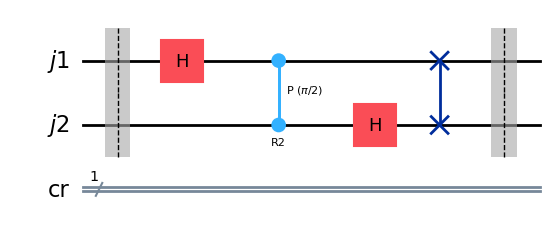

In [ ]:
# IMPORTANT NOTE: The readings in Qiskit should be done from bottom up.
#                 The most significant bit (the leftmost in a table or
#                 matrix is the one at the BOTTOM).

# Circuit definition
j1 = qk.QuantumRegister(1,'j1')
j2 = qk.QuantumRegister(1,'j2')
cr = qk.ClassicalRegister(1,"cr")
qc = qk.QuantumCircuit(j1,j2,cr)

qc.barrier()
qc.h(j1)
qc.cp(2*np.pi*(1/4),j2,j1,"R2")
qc.h(j2)
qc.swap(j1,j2)
qc.barrier()

# This is needed to compare the standard QFT matrix
#  with the QFT Qiskit matrx. Qiskit uses little endian
#  convention where "01" is in fact "10". Therefore
#  the rows and columns of 01 must become 10 and
 # vice-versa so the matrices can be compared.
QFT_qk = Operator(qc).data*2
QFT_qk[[1,2],:] = QFT_qk[[2,1],:]
QFT_qk[:,[1,2]] = QFT_qk[:,[2,1]]
QFT_qk
display(QFT_qk)

# Measurements
#qc.measure(j2,cr)
display(qc.draw('mpl'))

# Transpilation, simulation and results plotting
#plot_counts(qc)

In [ ]:
# Here we calculate the QFT matrix using only linear algebra

import numpy as np
import sympy as sp
from sympy.physics.quantum import TensorProduct as kron

I = sp.eye(2)
H = sp.Matrix([[1,1],[1,-1]])
IH = kron(I,H); IH
cp2 = sp.eye(4)
cp2[3,3] = sp.E**(2*sp.pi*sp.I/2**2); cp2
HI = kron(H,I); HI
QFT = np.array(IH*cp2*HI)

# This switch of rows here happens to account for
#  the swap operation at the circuit end. It
#  happens in the rows because we want to switch
#  the position of the output bits and matrix
#  multiplication can be understood as an operation
#  where numbers go in through the columns and
#  come out through the rows.
QFT[[1,2],:] = QFT[[2,1],:]
sp.Matrix(QFT)

Matrix([
[1,  1,  1,  1],
[1,  I, -1, -I],
[1, -1,  1, -1],
[1, -I, -1,  I]])

Comparing the two matrices we see that their difference equals to 0 in all elements of the result. Note that the `sympy` matrix needed to be converted to a numpy complex matrix using the `.astype` method.

In [ ]:
QFT_qk - np.array(QFT).astype(np.complex128)

array([[-0.+0.j, -0.+0.j, -0.+0.j, -0.+0.j],
       [-0.+0.j,  0.-0.j,  0.+0.j, -0.+0.j],
       [-0.+0.j,  0.+0.j, -0.+0.j,  0.+0.j],
       [-0.+0.j, -0.+0.j,  0.+0.j,  0.-0.j]])

##### QFT of a 3 Qubit system

array([[ 1. +0.j ,  1. +0.j ,  1. +0.j ,  1. +0.j ,  1. +0.j ,  1. +0.j ,  1. +0.j ,  1. +0.j ],
       [ 1. +0.j ,  0.7+0.7j,  0. +1.j , -0.7+0.7j, -1. +0.j , -0.7-0.7j, -0. -1.j ,  0.7-0.7j],
       [ 1. +0.j ,  0. +1.j , -1. +0.j , -0. -1.j ,  1. +0.j ,  0. +1.j , -1. +0.j , -0. -1.j ],
       [ 1. +0.j , -0.7+0.7j, -0. -1.j ,  0.7+0.7j, -1. +0.j ,  0.7-0.7j,  0. +1.j , -0.7-0.7j],
       [ 1. +0.j , -1. +0.j ,  1. +0.j , -1. +0.j ,  1. +0.j , -1. +0.j ,  1. +0.j , -1. +0.j ],
       [ 1. +0.j , -0.7-0.7j,  0. +1.j ,  0.7-0.7j, -1. +0.j ,  0.7+0.7j, -0. -1.j , -0.7+0.7j],
       [ 1. +0.j , -0. -1.j , -1. +0.j ,  0. +1.j ,  1. +0.j , -0. -1.j , -1. +0.j ,  0. +1.j ],
       [ 1. +0.j ,  0.7-0.7j, -0. -1.j , -0.7-0.7j, -1. +0.j , -0.7+0.7j,  0. +1.j ,  0.7+0.7j]])

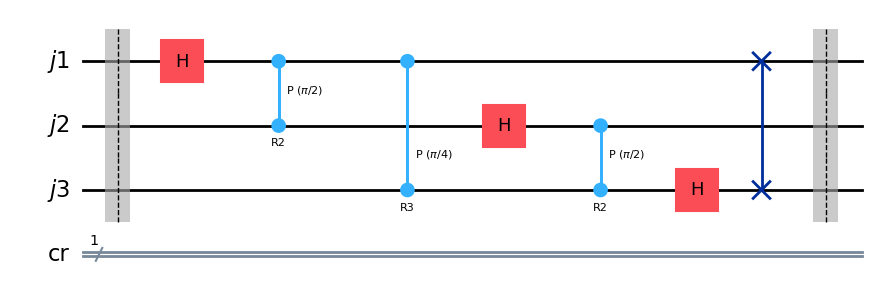

In [ ]:
# IMPORTANT NOTE: The readings in Qiskit should be done from bottom up.
#                 The most significant bit (the leftmost in a table or
#                 matrix is the one at the BOTTOM).

# Circuit definition
j1 = qk.QuantumRegister(1,'j1')
j2 = qk.QuantumRegister(1,'j2')
j3 = qk.QuantumRegister(1,'j3')
cr = qk.ClassicalRegister(1,"cr")
qc = qk.QuantumCircuit(j1,j2,j3,cr)

qc.barrier()
qc.h(j1)
qc.cp(2*np.pi*(1/4),j2,j1,"R2")
qc.cp(2*np.pi*(1/8),j3,j1,"R3")
qc.h(j2)
qc.cp(2*np.pi*(1/4),j3,j2,"R2")
qc.h(j3)
qc.swap(j1,j3)
qc.barrier()

QFT_qk = Operator(qc).data * (8**0.5)
# Little endian to Big endian convention
# 000 -> ok
# 001 -> 100 (1->4)
# 010 -> ok
# 011 -> 110 (3->6)
# 100 -> 001 (4->1)
# 101 -> ok
# 110 -> 011 (6->3)
# 111 -> ok
QFT_qk[:,[1,3,4,6]] = QFT_qk[:,[4,6,1,3]]
QFT_qk[[1,3,4,6],:] = QFT_qk[[4,6,1,3],:]
np.set_printoptions(precision=1, suppress=True, linewidth = 100)
display(QFT_qk)

# Measurements
#qc.measure(j2,cr)
display(qc.draw('mpl'))

# Transpilation, simulation and results plotting
#plot_counts(qc)

The circuit below shows an example of a Controlled R3 gate where the control bit is $j_3$ and the target bit is $j_1$. $j_2$ remains the same. If you look at it, the matrix applies the factor $e^{2 \pi i / 2^3} = e^{\pi / 4}$ only when both $j_1$ and $j_3$ are equal to $1$. In other words in bits $101$ and $111$.

array([[1.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ],
       [0.   , 1.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ],
       [0.   , 0.   , 1.   , 0.   , 0.   , 0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.   , 1.   , 0.   , 0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 1.   , 0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.707, 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 1.   , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.707]])

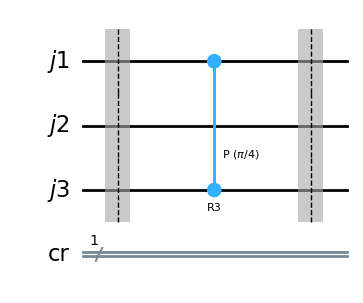

In [ ]:
# IMPORTANT NOTE: The readings in Qiskit should be done from bottom up.
#                 The most significant bit (the leftmost in a table or
#                 matrix is the one at the BOTTOM).
import qiskit as qk
from qiskit.quantum_info.operators import Operator

# Circuit definition
j1 = qk.QuantumRegister(1,'j1')
j2 = qk.QuantumRegister(1,'j2')
j3 = qk.QuantumRegister(1,'j3')
cr = qk.ClassicalRegister(1,"cr")
qc = qk.QuantumCircuit(j1,j2,j3,cr)

qc.barrier()
qc.cp(2*np.pi*(1/8),j3,j1,"R3")
qc.barrier()
display(Operator(qc).data.real)

# Measurements
#qc.measure(j2,cr)
display(qc.draw('mpl'))

# Transpilation, simulation and results plotting
#plot_counts(qc)

In [ ]:
import numpy as np
import sympy as sp
from sympy.physics.quantum import TensorProduct as kron

I = sp.eye(2)
H = sp.Matrix([[1,1],[1,-1]])
IIH = kron(I,I,H); IIH

cp2 = sp.eye(4)
cp2[3,3] = sp.E**(2*sp.pi*sp.I/2**2); cp2

Icp2 = kron(I,cp2);Icp2

cp13 = sp.eye(8)
cp13[5,5] = sp.E**(2*sp.pi*sp.I/2**3)
cp13[7,7] = sp.E**(2*sp.pi*sp.I/2**3); cp13

IHI = kron(I,H,I); IHI

cp2I = kron(cp2,I); cp2I

HII = kron(H,I,I); HII

QFT = IIH * Icp2 * cp13 * IHI * cp2I * HII
QFT = np.array(QFT)
QFT[[1,4],:] = QFT[[4,1],:]
QFT[[3,6],:] = QFT[[6,3],:]
QFT = sp.Matrix(QFT)
QFT = QFT.expand(complex=True)
QFT = sp.simplify(QFT)
QFT

Matrix([
[1,                  1,  1,                  1,  1,                  1,  1,                  1],
[1,  sqrt(2)*(1 + I)/2,  I, sqrt(2)*(-1 + I)/2, -1, sqrt(2)*(-1 - I)/2, -I,  sqrt(2)*(1 - I)/2],
[1,                  I, -1,                 -I,  1,                  I, -1,                 -I],
[1, sqrt(2)*(-1 + I)/2, -I,  sqrt(2)*(1 + I)/2, -1,  sqrt(2)*(1 - I)/2,  I, sqrt(2)*(-1 - I)/2],
[1,                 -1,  1,                 -1,  1,                 -1,  1,                 -1],
[1, sqrt(2)*(-1 - I)/2,  I,  sqrt(2)*(1 - I)/2, -1,  sqrt(2)*(1 + I)/2, -I, sqrt(2)*(-1 + I)/2],
[1,                 -I, -1,                  I,  1,                 -I, -1,                  I],
[1,  sqrt(2)*(1 - I)/2, -I, sqrt(2)*(-1 - I)/2, -1, sqrt(2)*(-1 + I)/2,  I,  sqrt(2)*(1 + I)/2]])

In [ ]:
delta = (QFT_qk - np.array(QFT).astype(np.complex128))
(np.abs(delta) < 1e-15).all()

True

### **END OF FILE**

Célula inserida para manter os links acima dela fechados caso ocorra uma inserção de fim de arquivo